In [1]:

"""
QRC implementation using quantum circuits

I tested different circuit structures and found out that a circuit that performed well on linear and nonlinear tasks used series of Ryy-entanglement gates and CNOT-gates.
In addition using the Rz-rotation gates provided some useful mixing. 

This application is mostly consistent with 4 qubits but is scalable. For real hardware the implementation needs some changes as well


QUICK SUMMARY:

Note: Some features have been removed, but some residual code may still remain

Readout options :
  "probs" : 15 features, probs[:-1]  -> use probabilities
  "paulis": 21 features,  <X>,<Y>,<Z> on all qubits. Two qubit expectation values <XY> etc. on last two qubits -> this is used for the thesis

Encoding options : 
    "ry" : uses R_y rotation gate for encoding  -> this is used for the thesis
    "ry_rx" : uses R_y and R_x gates in series for encoding
    "random_axes" : uses a random rotation through a fixed axis -> rotation gate R_n

Circuit options :
    "ryy" : as stated above, contains series of R_yy, CNOT and R_Z gates
    Other circuit options were later removed

Multiplexing options (NOT USED ON THE FINAL IPC CALCULATIONS): 
    Time multiplexing: measure multiple times within a step
    Spatial mutliplexing: run multiple reservoirs in parallel



IPC and the digital twin:
    Sweep through the original reservoir's basis (Legendre polynomials) -> find the relevant polynomials and get the series expansion coefficients 
    Using these coefficients construct a digital twin to mimic the real reservoir

    The coefficients are approximated using ensemble average as roughly (1/N)sum(O_iP_d_i), N is the number of timesteps, O_i observable, and P_d_i is the Legendre polynomial(s). 

Plots and tasks:
    Linear memory capacity of the reservoir. Two calculations, one using C=1-NMSE, other using the coefficients
    Bar plot showing the term distribution per delay (polynomial degree + cross-terms)
    Reconstruction of an original observable using the series expansion

    NARMA-2 and NARMA-5 for the real reservoir and the digital twin
    Correlated NARMA-5 for the real reservoir and the digital twin
    MSE sweep plot (NARMA-2) using normally distributed input with different standard deviations (10 different seeds for input)
"""




import time
import numpy as np
import itertools
from itertools import combinations
import os
from numpy.polynomial.legendre import legval
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix, SparsePauliOp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

rng = np.random.default_rng(42)


############################################
# These parameteres define some fundamental properties of the circuit and how it processes information
############################################
Q_N=4                       # Number of qubits
Encode_N= 2                # How many qubits are we using for encoding
Reset_N= 2               # How many qubits do we reset
Enc_str= [0.2, 0.2]       # Defines the encoding "strength" as R_y[(ENC_str)π s_t]. For qubits 1 and 2
Enc_str1=0.2            # If just encoding to one qubit
Enc= "ry"      # Defines what input encoding gate is used. I implemented other gates as well for testing, "ry_rx" and "random_axes". The "random_axes" uses some random rotation through a fixed axis so  R_n(s_t)
Circuit   = "ryy" # The structure of the circuit.
Ryy_dist = rng.uniform(0.3, 0.7, Q_N-1) # Distribution for Ryy angles. I went through different seeds to find "good" angles
R_z= rng.uniform(0.1, 0.4, Q_N) # Distribution for the rotation Rz gate angle
gate_str= 0.5 # This defines the strength of entanglement-gates. 
Ryy= Ryy_dist * gate_str  # The actual gate parameters used. 
Passes=  2     # Number of times one input goes through a gate sequence. The one used for IPC is two
# These are for the "arbitrary" encoding, the parameters are choosed randomly
After_encode= False  # THIS IS IMPORTANT! False also makes the "Passes" above work as intended. If this is True and the Passes=2 is used, we essentially use time multiplexing. 
Arb_rand= rng.uniform(-1, 1, 150)
Arb_axes= np.random.default_rng(seed=99)
Enc_axes= []
for _ in range(Encode_N):  # The _ suffices because we don't actually care about the indexes as we don't use them. 
    n= Arb_axes.standard_normal(3)
    n= n/np.linalg.norm(n)
    Enc_axes.append(n)

############################################
# These are all the parameters needed to compute the information processing capacity
############################################
washout= 100     
s_t= 100000     # input sequence (without the washout and test sequence)
test = 2000     # Length of test sequence
tau_max= 12     # Maximum delay for IPC
d_max= 4        # Maximum degree of single Legendre polynom
cross_max= 3    # Maximum number of single Legendre polynoms on one term
c_treshold  = 5e-4 # Treshold for capacity. This is essentially the epsilon=0.0005


############################################
# Measurements and readout 
############################################

Readout="paulis"  # "paulis" and "probs" , "paulis" uses the observables and "probs" uses the normal measurement probabilities (shots)
Measure_all=True     # Measure all qubits or no
Features_probs=2**Q_N - 1   #How many features if readout is "probs"
Mem_Q_n= Q_N-Encode_N    # Defines the memory qubits
Measure_reset= True   # Do we measure before reset


############################################
# Here I tried to implement multiplexing. THESE WERE NOT USED IN IPC CALCULATIONS 
############################################
# Spatial multiplexing, run multiple independent reservoirs with different random parameters and combine the features
# Time multiplexing, extract information about the observables multiple times within one step

spatial_N= 1       #number of independent reservoirs, this is the normal value           
spatial_seeds= [42,99,123]  #Seeds for the parameters of different reservoirs
Time_m= False  # If True, measure at multiple points within a step             



############################################
# The circuit construction functions, these are implemented to work with multiplexing. For this reason, some of the segments are build as "steps"
############################################

#Defines what implementation is used for encoding
def encode_qubit(qc, u, qubit, alpha_i, spatial_axes=None):
    axes = spatial_axes if spatial_axes is not None else Enc_axes #For the "arbitrary" encoding
    if Enc== "ry":
        qc.ry(alpha_i * np.pi*u,qubit)  #This is what we use for IPC
    elif Enc=="ry_rx":             # The encoding for Ry and Rx gates is used.
        qc.ry(alpha_i*np.pi*u,qubit)
        qc.rx(alpha_i*np.pi*u,qubit)
    elif Enc== "random_axes":   # The encoding that uses arbitrary axes
        nx,ny, nz= axes[qubit if qubit < len(axes) else 0]
        _alpha= float(np.arctan2(ny, nx))
        _beta= float(np.arccos(np.clip(nz, -1, 1)))
        qc.rz(-_alpha,qubit)
        qc.ry(-_beta, qubit)
        qc.rz(alpha_i*np.pi * u, qubit)
        qc.ry(_beta,qubit)
        qc.rz(_alpha,qubit)


# Defines how many qubits are used for encoding when circuit is built
def encode_circuit(u, spat_Yy=None, spat_Rz=None, spatial_axes=None):
    qc= QuantumCircuit(Q_N)
    if Encode_N== 1:
        encode_qubit(qc,u, 0,Enc_str1, spatial_axes)
    else:                   
        for i in range(Encode_N):       #We use Encode_N=2 for IPC calculations
            alpha_i= (Enc_str[i]
                       if i< len(Enc_str) else Enc_str1)  
            encode_qubit(qc,u, i,alpha_i, spatial_axes)
    return qc


# The gate sequence itself. If spatial multiplexing is not used, the standard gate composition of Ryy defined above is used with the determined seed value (42)
def ryy_pass_circuit(spat_Yy=None, spat_Rz=None):
    Yy_=spat_Yy if spat_Yy is not None else Ryy
    Rz_=spat_Rz if spat_Rz is not None else R_z
    qc = QuantumCircuit(Q_N)
    for i in range(Q_N - 1):
        qc.cx(i, i + 1)          # The CNOT-gates
        qc.ryy(2 * Yy_[i],i, i + 1) # The Ryy-gates
    for i in range(Q_N):
        qc.rz(2 * Rz_[i], i)    # The Rz-gates
    return qc


# The reservoir. This constructs the reservoir using the "Passes"-parameter -> how many ryy_pass_circuits are used. 
def reservoir_step(u, spat_Yy=None, spat_Rz=None, enc_axes_sp=None):
    qc = QuantumCircuit(Q_N)
    qc.compose(encode_circuit(u, spat_Yy, spat_Rz, enc_axes_sp), inplace=True)
    for _ in range(Passes):
        qc.compose(ryy_pass_circuit(spat_Yy, spat_Rz), inplace=True)
    return qc




############################################
# These are for the observables. Qiskit uses unconventional order so it is reversed here. Also because these are needed for multi-qubit operations 
############################################

#To build a string for the Pauli operators (observables). For example "IXYI", I is just the identity operator.
def _pauli_str(pauli, qubit):
    
    s = ["I"] * Q_N
    s[Q_N - 1 - qubit] = pauli   # Qiskit uses highest index for leftmost qubit
    return "".join(s)

# The string values for the Paulis
_P= ["X", "Y", "Z"]

# Defines memory qubits and "active" qubits. Active are all the ones measured. Counter intuitive in a sense, because if all the qubits are not measured, the memory ones are.
# This is because Initially I wanted to measure only the qubits that are not used for encoding
Memory= list(range(Encode_N, Q_N))   
Active= list(range(Q_N)) if Measure_all else Memory


# All the single + two qubit Paulis. This is Because a feature matrix is created later.
Paulis_N= 3*len(Active) + 9
Features= (Paulis_N if Readout == "paulis" else Features_probs)

# This determines snapshots for time multiplexing. Not used on the IPC 
Snapshot_N= (1 if not Time_m else
                Passes + 1 if After_encode else
                Passes)
features_N= Features *Snapshot_N  # As if snapshot_N > 1, the feature matrix get specific columns for the "per snapshot" features
# Labels for the observables for different time multiplexing steps
if Time_m:
    Pauli_labels= None   

#Single paulis for all the qubits measured, the "active" qubits
Observables_single= [SparsePauliOp(_pauli_str(p, q))
                   for q in Active for p in _P]
Observables_labels_single= [f"{p}_q{q}" for q in Active for p in _P]

#These are the multi-qubit observables. Only the memory qubit correlations are taken into account (the ones with no encoding)
_multiple_qubits_obs= Active[-2:]   # last two active qubits for correlators, so the memory ones
Correlation_obs= (
    [SparsePauliOp(_pauli_str(p, q)) for q in Active for p in _P] +
    [SparsePauliOp(SparsePauliOp(_pauli_str(p, _multiple_qubits_obs[1])) @
                   SparsePauliOp(_pauli_str(q, _multiple_qubits_obs[0])))
     for p in _P for q in _P]
)
Correlation_obs_labels= (
    [f"{p}_q{q}" for q in Active for p in _P] +
    [f"{p}_q{_multiple_qubits_obs[1]}_{q}_q{_multiple_qubits_obs[0]}" for p in _P for q in _P]
)


Observables, Observable_labels= Correlation_obs, Correlation_obs_labels

# For time multiplexing, the labels for the observables need to have a "time" label. This is not necessary, because the features are combined but I found it useful to label them in testing
if Time_m:
    _snap_labels= (
        ["v0"]+ [f"v{p+1}" for p in range(Passes)] if After_encode
        else [f"v{p+1}" for p in range(Passes)])
    Observables_labels_all=[f"{lbl}_{s}"
                        for s in _snap_labels
                        for lbl in Observable_labels]
else:
    Observables_labels_all= Observable_labels

# This is for the actual feature extraction. If we use Readout="probs", we get the probabilities, else we get the expectation values
def get_features(state):
    if Readout== "probs":
        return state.probabilities()[:-1]   # 15 features
    else:
        return np.array([
            float(np.real(state.expectation_value(op)))
            for op in Observables])  


############################################
# The runners. The first one is used to run the actual reservoir, the second one takes into account how many reservoirs to run -> spatial multiplexing
############################################

def run_one_reservoir(u_seq, Ryy_spat, Rz_spat, enc_axes_sp): # Gets the input and parameters depending on the encoding-scheme. 
    """
    Runs a single reservoir with given reservoir parameters
    Returns a matrix X that includes the features per timestep
    """
    N= len(u_seq)  # The timesteps
    X=np.zeros((N, features_N)) # Create the matrix 
    state= DensityMatrix.from_label("0" * Q_N) # This creates the density matrix. It is initialized in the ∣0⟩ basis state
    print("Running input")
    for t in range(N): # Iterate over the timesteps
        if t % 4000== 0 and t > 0:    # This is just a continuous confirmation that the reservoir is running
            print(f"{t}/{N}", flush=True)


       
        # This one takes account time-multiplexing as snapshots are used for each pass. The latter is the "normal" one
        if Time_m:
            state= state.evolve(encode_circuit(u_seq[t], Ryy_spat, Rz_spat, enc_axes_sp)) 
            F= Features
            snap= 0
            if After_encode:      # Is the state measured straight after encoding? If no, this is skipped
                X[t, snap*F:(snap+1)*F] = get_features(state)
                snap += 1
            for p in range(Passes):    # The other snapshots
                state = state.evolve(ryy_pass_circuit(Ryy_spat, Rz_spat))
                X[t, snap*F:(snap+1)*F] = get_features(state)
                snap += 1
            state= state.reset(list(range(Reset_N)))


        # This is the one used for IPC. Signal goes through the reservoir and is measured just in the end
        else:
            state= state.evolve(reservoir_step(u_seq[t], Ryy_spat, Rz_spat, enc_axes_sp))
            X[t]= get_features(state)
            state= state.reset(list(range(Reset_N)))

    return X


def run_reservoir(u_seq):
    """
    Runs the given sequence through the reservoir
        if spatial_N=1, use only the above function
        if spatial_N>1, use the above function for multiple reservoirs
    """ 
    if spatial_N== 1:
        return run_one_reservoir(u_seq, Ryy, R_z, Enc_axes)  # These are the "normal" parameters for one reservoir

    # Spatial multiplexing — run multiple independent reservoirs
    X_list = []
    for s_idx in range(spatial_N):
        seed= spatial_seeds[s_idx] if s_idx < len(spatial_seeds) else s_idx  #the seeds for the reservoirs
        rng_sp= np.random.default_rng(seed)
        spat_Yy= rng_sp.uniform(0.3, 0.7, Q_N - 1) * gate_str
        spat_Rz= rng_sp.uniform(0.1, 0.4, Q_N)
        axes_sp= [] # Random encoding axes for this spatial reservoir
        rng_ax_sp= np.random.default_rng(seed + 1000)
        for _ in range(Encode_N):
            n= rng_ax_sp.standard_normal(3) # Make a 3D vector that gets values from 0 to 1
            axes_sp.append(n / np.linalg.norm(n)) # Normalize the vector -> Bloch sphere
       
        X_sp= run_one_reservoir(u_seq, spat_Yy, spat_Rz, axes_sp)
        X_list.append(X_sp)  # Save the results of each reservoir

    return np.concatenate(X_list, axis=1)  # Combine the results

############################################
# PCA, this is essentially ortonormalization. Used for decorrelation and to get normalized features. Necessary for the IPC
# The function gets training and testing features as values
############################################

def ortonormal(X_tr, X_te):
    mu= X_tr.mean(0, keepdims=True)  # Calculate the mean
    X_tr= X_tr- mu # Subtract the mean from both training and test
    X_te= X_te-mu 
    R= X_tr.T @ X_tr /len(X_tr) # The covariance matrix
    U,variance_per_axes ,Principal_axes= np.linalg.svd(R, full_matrices=False)  # Singular value decomposition, U and Principal_axes is essentially the same
    k= int(np.sum(variance_per_axes> 1e-6 * variance_per_axes[0])) # Keep the necessary dimensions, we use all.
    W= Principal_axes[:k].T*(1.0 / np.sqrt(variance_per_axes[:k])) # The actual transformation, so that ortonormalized features X_ort=XW. Has zero mean and covariance is roughly the identity
    W_inv= Principal_axes[:k]*np.sqrt(variance_per_axes[:k])[:, np.newaxis] # Inverse of the transformation. This is needed for building the exact original observables
    return X_tr @ W,X_te @ W, k, mu, W, W_inv 





############################################
# The Legendre polynomials and the capacity itself
############################################

# Defines normalized Legendre polynomials (degree of D at some timestep u)
def legendre_poly(u, d):  
    c= np.zeros(d + 1) # The coefficients c_i for c_iP_d need to be initialized to use the legval function. This way the specific degree polynom P_d can be used for iteration
    c[d] = 1.0 # instead of zero, the wanted degree gets 1
    return np.sqrt(2*d + 1) * legval(u, c) # For example, if c=[0,0,1] this chooses P_2(u)

# Capacity calculation, takes the ortonormalized features and the Legendre polynomials  as parameters. The poly_d_tau is degree d Legendre polynomial applied to the input over time. So P_d(s_t)
def capacity(X_ort, poly_d_tau):
    N= len(poly_d_tau) # This is the size of the sequence that gets through the Legendre polynomials
    average_poly= float(np.mean(poly_d_tau**2)) # calculate the mean squared value of the Legendre polynomials
    if average_poly < 1e-12: return 0.0 #For stability as some values are very small
    c= X_ort.T @ poly_d_tau / N          #This is the ensemble average, the product between the features and the polynomials divided by timesteps N. So the "time average"-> the coefficients
    return float(c@ c)/ average_poly   # The actual capacity, divided with the average polynomial value. This way it can be compared


 # A function to calculate the capacity through 1-NMSE
def nmse_rec_cap(X_tr_ort, X_te_ort, target_tr, target_te):
    N= len(target_tr)
    average_poly= float(np.mean(target_tr**2))
    if average_poly < 1e-12: return 0.0
    c= X_tr_ort.T @ target_tr / N  # Fit coefficients on training 
    pred = X_te_ort @ c     # Predict on test 
    var= float(np.var(target_te)) # Variance test for stability
    if var < 1e-12: return 0.0
    nmse= float(np.mean((target_te- pred)**2) / var) # NMSE between the target and the prediction
    return float(max(0.0, 1.0 - nmse))


# Print the circuit 
qc_s= reservoir_step(1)
ops= qc_s.count_ops()
print(qc_s.draw())


     ┌─────────┐     ┌───────────────┐┌─────────────┐                 »
q_0: ┤ Ry(π/5) ├──■──┤0              ├┤ Rz(0.61842) ├─────────────────»
     ├─────────┤┌─┴─┐│  Ryy(0.60958) │└─────────────┘┌───────────────┐»
q_1: ┤ Ry(π/5) ├┤ X ├┤1              ├───────■───────┤0              ├»
     └─────────┘└───┘└───────────────┘     ┌─┴─┐     │  Ryy(0.47555) │»
q_2: ──────────────────────────────────────┤ X ├─────┤1              ├»
                                           └───┘     └───────────────┘»
q_3: ─────────────────────────────────────────────────────────────────»
                                                                      »
«                                     ┌───────────────┐┌─────────────┐»
«q_0: ───────────────────────■────────┤0              ├┤ Rz(0.61842) ├»
«     ┌─────────────┐      ┌─┴─┐      │  Ryy(0.60958) │└─────────────┘»
«q_1: ┤ Rz(0.25651) ├──────┤ X ├──────┤1              ├───────■───────»
«     └─────────────┘┌─────┴───┴─────┐└┬─────────────┬┘     ┌─┴─

In [2]:
# Generate input, the training, testing split is also made
Whole_seq= washout + s_t + test
u_seq= rng.uniform(-1, 1, Whole_seq)
u_tr = u_seq[washout : washout + s_t] # Training sequence
u_te= u_seq[washout + s_t:]   # Testing sequence

# Run the reservoir. Save the features to X_full. Contains the "original" observables
X_full= run_reservoir(u_seq)
X_tr_obs = X_full[washout : washout + s_t]  # Training observables
X_te_obs= X_full[washout + s_t:]   # Testing observables

# Ortonormalize the features
X_tr_ort, X_te_ort,dim, feature_mean,coeff_norm, W_inv= ortonormal(X_tr_obs, X_te_obs)

# These functions are for the delayed polynomials both training and testing. Calculates the polynomials
def poly_tr(tau, d):
    unprocessed= legendre_poly(u_tr[:s_t - tau], d)
    return unprocessed - unprocessed.mean()

def poly_te(tau, d):
    unprocessed= legendre_poly(u_te[:test - tau], d)
    return unprocessed - unprocessed.mean()

Running input
4000/102100
8000/102100
12000/102100
16000/102100
20000/102100
24000/102100
28000/102100
32000/102100
36000/102100
40000/102100
44000/102100
48000/102100
52000/102100
56000/102100
60000/102100
64000/102100
68000/102100
72000/102100
76000/102100
80000/102100
84000/102100
88000/102100
92000/102100
96000/102100
100000/102100


In [3]:
###
# Linear memory capacity. Two approaches, one using the linear polynomials, the other using 1-NMSE
# Both are insample, this affected the total capacity  around 0.02, the risk of overfitting is low
###

# This uses polynomials
lin_mc= {}
for tau in range(tau_max + 1): 
    p_tr= poly_tr(tau, 1)
    cap= capacity(X_tr_ort[tau:], p_tr)
    lin_mc[tau]= cap 
    print(f"  {tau:<5} {cap:>10.5f}")

lin_mc_tot= sum(lin_mc.values())

print(f"\n Total linear mc (capacity formula)= {lin_mc_tot:.4f}")

# This uses 1-NMSE
total_nmse_c = 0.0
for tau in range(tau_max + 1):
    L= s_t - tau
    p= legendre_poly(u_tr[:L], 1)
    p= p- p.mean()
    total_nmse_c += nmse_rec_cap(X_tr_ort[tau:], X_tr_ort[tau:], p, p)

print(f" Total linear mc (1-NMSE)=  {total_nmse_c:.4f}")






  0        0.99858
  1        0.98954
  2        0.96927
  3        0.96062
  4        0.90556
  5        0.84745
  6        0.48059
  7        0.34518
  8        0.10981
  9        0.06958
  10       0.03820
  11       0.02280
  12       0.01580

 Total linear mc (capacity formula)= 6.7530
 Total linear mc (1-NMSE)=  6.7529


In [ ]:
############################################
# The IPC calculation, this sweeps the Legendre basis.
# For reference, the singular terms are only printed. It can be seen that the  capacity associated with linear terms P_1 are the same as above.
# Some features here were used for testing that I removed later. This means that here is no R^2 score calculations. 
############################################

terms= []
C_total= 0.0

# The delays are aligned to the data, so increasing tau_max, the sweep goes further. BUT it is redundant in this case
for delay in range(tau_max + 1):
    print(f"\n  tau={delay} {"":<50} C:")
    L= s_t - delay
    Xs= X_tr_ort[delay:]
    found_taus= sorted(set(t for f in terms for t in f["taus"]))

    # Single termms, so only singular Legendre polynomials
    for d in range(1, d_max + 1):
        p= poly_tr(delay, d)
        cap= capacity(Xs, p)
        if cap < c_treshold:
            continue  # If the capacity is under the treshold, discard the term
        C_total+= cap # Add the capacity to total value
        lbl= f"P{d}(u_t-{delay})" # For labeling
        p_te_= poly_te(delay, d)  # Delayed polynomials
        terms.append(dict(label=lbl, order=1, taus=(delay,), # Dictionary is made for easier acces to different terms
                          ds=(d,), cap=cap, tau_max=delay,   # This is very importan for the twin implementation
                          poly_tr=p, poly_test=p_te_))
        print(f"  {lbl:<55} {cap:>8.5f} ")

    # Cross-terms with two terms. Same principle as above
    if cross_max >= 2:
        for tau_prev in found_taus: # Previous delays, so no duplicates and only accepted terms
            if tau_prev >= delay: 
                continue
            offset = delay - tau_prev # The different sequences used in the polynomials need to be aligned.
                                      # This way the sequences are from the same point of time
            for d1 in range(1, d_max + 1): # Calculate both polynomials
                for d2 in range(1, d_max + 1):
                    p= (legendre_poly(u_tr[:L], d1) *
                           legendre_poly(u_tr[offset:offset+L], d2))
                    p= p - p.mean()  # Zero mean, for capacity calc
                    cap = capacity(Xs, p)
                    if cap < c_treshold: # Again check the treshold
                        continue
                    C_total += cap
                    lbl= f"P{d1}(u_t-{delay}) x P{d2}(u_t-{tau_prev})" # Same as above, save to dictionary. Now there is just two polynomials
                    L_te= test - delay
                    p_te_= (legendre_poly(u_te[:L_te], d1) *legendre_poly(u_te[offset:offset+L_te], d2))  
                    p_te_ = p_te_ - p_te_.mean()
                    terms.append(dict(label=lbl, order=2,
                                      taus=(delay, tau_prev),
                                      ds=(d1, d2), cap=cap,
                                      tau_max=delay,
                                      poly_tr=p, poly_test=p_te_))
                    

    # Cross-terms with three terms. Same principle as above
    if cross_max >= 3 and len(found_taus) >= 2:
        for tau_p1, tau_p2 in combinations(found_taus, 2):  # Two already accepted terms
            if tau_p1 >= delay or tau_p2 >= delay: # To check order
                continue
            offset1 = delay - tau_p1  # These are again for the alignments
            offset2 = delay - tau_p2
            for d1, d2, d3 in itertools.product(range(1, d_max+1), repeat=3): # Construct a term with three polynomials
                p= (legendre_poly(u_tr[:L], d1) *
                       legendre_poly(u_tr[offset1:offset1+L], d2) *
                       legendre_poly(u_tr[offset2:offset2+L], d3))
                p= p - p.mean()    # Zero mean
                cap = capacity(Xs, p)
                if cap < c_treshold: continue
                C_total += cap
                lbl = (f"P{d1}(u_t-{delay}) x "
                       f"P{d2}(u_t-{tau_p1}) x P{d3}(u_t-{tau_p2})") # The labels and all that
                L_te= test - delay
                p_te_= (legendre_poly(u_te[:L_te], d1) * legendre_poly(u_te[offset1:offset1+L_te], d2) * legendre_poly(u_te[offset2:offset2+L_te], d3))
                p_te_ = p_te_ - p_te_.mean() 
                terms.append(dict(label=lbl, order=3,
                                  taus=(delay, tau_p1, tau_p2),
                                  ds=(d1, d2, d3), cap=cap,
                                  tau_max=delay,
                                  poly_tr=p, poly_test=p_te_))
                

    

# As there were a lot of small terms that overshot the capacity bound, here they are trimmed
# Larger treshold would help with this problem but in the end it does not matter much, because the relevant terms are there
# Most of the trimmed terms were the order 3 cross-terms which introduce "statistical noise" anyway

terms= sorted(terms, key=lambda f: -f["cap"]) # Sort first, then start to add so that the total capacity bound is respected
terms_it= []
C_t = 0.0
for f in terms:
    if C_t >= dim: break
    terms_it.append(f); C_t += f["cap"] 
terms   = terms_it
C_total = C_t



############################################
# Here the actual coefficients are made. THIS PART IS VERY DESIGN dependent and can be done differently
# My idea was that that the coefficients for each observable are saved in vectors and then can be multiplied with the relevant Legendre polynomials. 
############################################

# These splits are for consistent data usage when maximux delay is used
L_tr= s_t - tau_max
L_te= test- tau_max
N_terms= len(terms)

# Compute coefficients directly: so roughly c[j, k] = <obs, Legendre> / N_j
C_coeff = np.zeros((N_terms, dim))  
for j, f in enumerate(terms):
    tau_j=f["tau_max"]
    N_j=s_t - tau_j
    # This same procedure is used in the capacity calculation
    C_coeff[j] =X_tr_ort[tau_j:].T @ f["poly_tr"] / N_j  # So each feature gets a vector of coefficients that is later multiplied with the basis functions

# The B matrices consist of the Legendre basis functions so that the coeffiecients are aligned with them.
# As the B depends on the input, of course it is calculated again when input changes. This can be seen when using the actual twin.
B_tr= np.zeros((L_tr, N_terms)) # Training set
B_te= np.zeros((L_te, N_terms)) # Testing set
for j, f in enumerate(terms):  
    tau_j = f["tau_max"]
    offset_tr= tau_max - tau_j 
    offset_te= tau_max - tau_j
    B_tr[:, j] = f["poly_tr"][offset_tr : offset_tr + L_tr]
    B_te[:, j] = f["poly_test"][offset_te : offset_te + L_te]



############################################
# We want to see how the actual observables can be constructed from the terms.
# So this part is for the observable reconstruction plot
############################################

# Training and testing alignment as first delays up to tau_max is discarded
X_tr_aligned= X_tr_ort[tau_max:]   
X_te_aligned= X_te_ort[tau_max:]   

# The actual  X_pred = B @ C_coeff
# C_coeff[j,k], term j and feature k
X_pred_tr= B_tr @ C_coeff 
X_pred_te= B_te @ C_coeff 


# Invert orthonormalization: 
# This way the reconstruction happens in the same scale as the original observables
X_te_orig=X_te_aligned  @ W_inv + feature_mean   
X_pred_orig=X_pred_te     @ W_inv + feature_mean   


  tau=0                                                    C:
  P1(u_t-0)                                                0.99858 
  P2(u_t-0)                                                0.99581 
  P3(u_t-0)                                                0.33058 
  P4(u_t-0)                                                0.01203 

  tau=1                                                    C:
  P1(u_t-1)                                                0.98954 
  P2(u_t-1)                                                0.75755 
  P3(u_t-1)                                                0.04578 
  P4(u_t-1)                                                0.00177 

  tau=2                                                    C:
  P1(u_t-2)                                                0.96927 
  P2(u_t-2)                                                0.42673 
  P3(u_t-2)                                                0.01814 
  P4(u_t-2)                                                0.00

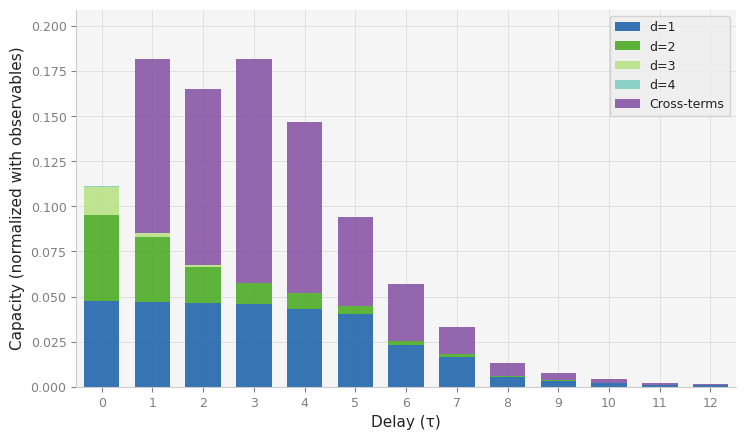

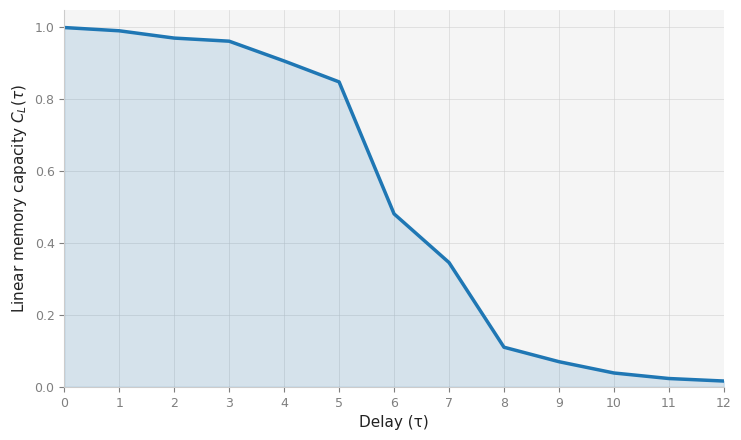

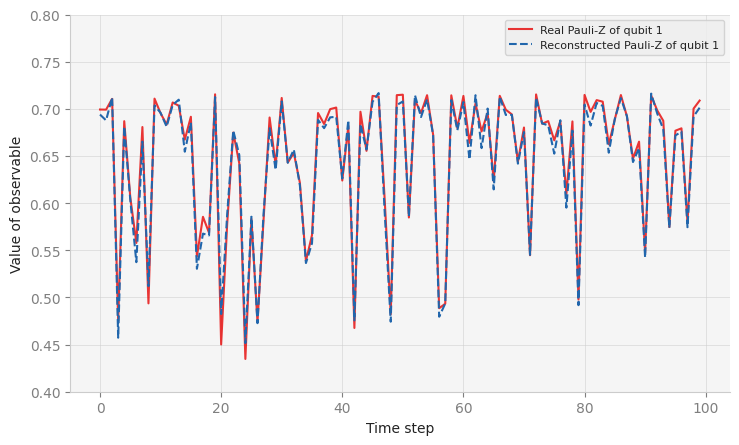

In [ ]:
############################################
# The plots.
# Some implementations might be "redundant" because I plotted all kinds of things at first but removed them later
############################################

tau_arr= np.arange(tau_max + 1) # Array for taus
mc_arr= np.array([lin_mc[t] for t in tau_arr]) # Array for linear capacity terms
lin_terms_ipc= np.zeros(tau_max + 1)  # The linear terms
nonlin_terms_ipc= np.zeros(tau_max + 1) # Nonlinear terms
for f in terms:
    t= f["tau_max"]
    if t <= tau_max:
        if f["order"]== 1 and f["ds"] == (1,): # Add the linear terms
            lin_terms_ipc[t] += f["cap"]
        else:        # Add the nonlinear terms
            nonlin_terms_ipc[t]  += f["cap"]

cap_by_order= {}   # The cross-term order, for a plot
for f in terms: 
    cap_by_order.setdefault(f["order"], 0.0)
    cap_by_order[f["order"]] += f["cap"]

caps_term_efficiency = np.cumsum([f["cap"] for f in terms]) # Order for the importance of terms


# Some style things
BLUE   = '#1f77b4'; ORANGE = '#d62728'; GREEN  = '#2ca02c'
PURPLE = '#9467bd'; GRAY   = '#7f7f7f'
BG     = '#ffffff'; PANEL  = '#f5f5f5'; BORDER = '#cccccc'
TEXT   = '#222222'; TITLE  = '#000000'

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=GRAY, labelsize=9)
    ax.xaxis.label.set_color(TEXT); ax.yaxis.label.set_color(TEXT)
    ax.set_title(title, color=TITLE, fontsize=10, pad=8, fontweight="bold")
    for sp in ax.spines.values(): sp.set_edgecolor(BORDER)
    ax.grid(True, color=BORDER, linewidth=0.5, alpha=0.7, zorder=0)
    ax.set_axisbelow(True)



matplotlib.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 10
})

############################################
# A bar plot that tells how different degrees and cross-terms contribute to the capacity
# and the linear capacity plot
############################################

fig1 = plt.figure(figsize=(20, 12))
fig1.patch.set_facecolor(BG)
gs2 = gridspec.GridSpec(2, 2, figure=fig1, hspace=0.45, wspace=0.35)
ax_1 = fig1.add_subplot(gs2[0, 0])  
ax_1.set_facecolor(PANEL)

# Compute per-term degree capacity per tau (order=1 only) (the fraction)
cap_by_perdeg=np.zeros((tau_max + 1, d_max))
for f in terms:
    if f["order"]== 1:
        d= f["ds"][0] - 1  
        tau= f["tau_max"]
        if tau<=tau_max and d < d_max:
            cap_by_perdeg[tau, d] += f["cap"]
# Cross-terms 
cross_by_tau=np.zeros(tau_max + 1)
for f in terms:
    if f["order"]>= 2:
        tau= f["tau_max"]
        if tau<= tau_max:
            cross_by_tau[tau]+= f["cap"]

PERDEG_COLORS= ['#2166ac', '#4dac26', '#b8e186', '#80cdc1',
                 '#d01c8b', '#ff7f00', '#6a3d9a', '#a6cee3']
CROSS_COLOR= '#8856a7'
PERDEG_LABELS= [f"d={d+1}" for d in range(d_max)]

# Start to construct from bottom. The single terms first
bottom = np.zeros(tau_max + 1)
for d in range(d_max):
    vals  =cap_by_perdeg[:, d] / features_N
    if vals.sum()> 0:
        ax_1.bar(tau_arr, vals, bottom=bottom,
                 color=PERDEG_COLORS[d], alpha=0.9, width=0.7,
                 label=PERDEG_LABELS[d])
        bottom   += vals

# Cross-terms on top
cross_norm =cross_by_tau / features_N
ax_1.bar(tau_arr,cross_norm, bottom=bottom,
         color=CROSS_COLOR, alpha=0.9, width=0.7,
         label="Cross-terms") # " cross-terms"

ax_1.axhline(1.0, color="white", lw=1.5, ls="--", alpha=0.5, label="")
ax_1.set_xlabel("Delay (τ)", color=TEXT, fontsize=11) # "Delay (τ)"
ax_1.set_ylabel("Capacity (normalized with observables)", color=TEXT, fontsize=11) 
ax_1.set_xlim(-0.5,tau_max + 0.5)
ax_1.set_ylim(0, max((bottom + cross_norm).max() * 1.15, 0.05))
ax_1.set_xticks(tau_arr)
ax_1.tick_params(colors=GRAY)
for sp in ax_1.spines.values(): sp.set_edgecolor(BORDER)
ax_1.legend(fontsize=9,facecolor="#eeeeee", labelcolor=TEXT,
            edgecolor=BORDER, loc="upper right")
style_ax(ax_1, "")

############################################
# The linear capacity plot
############################################
# The linear capacity plot
fig2 = plt.figure(figsize=(20, 12))
fig2.patch.set_facecolor(BG)
gs2 = gridspec.GridSpec(2, 2, figure=fig2, hspace=0.45, wspace=0.35)
ax_2 = fig2.add_subplot(gs2[0, 0])
ax_2.set_facecolor(PANEL)
ax_2.plot(tau_arr, mc_arr, lw=2.5, color=BLUE)
ax_2.fill_between(tau_arr, mc_arr, alpha=0.15, color=BLUE)
ax_2.set_xlabel("Delay (τ)", color=TEXT, fontsize=11) # 
ax_2.set_ylabel("Linear memory capacity $C_L(τ)$", color=TEXT, fontsize=11) 
ax_2.set_xlim(0, tau_max)
ax_2.set_ylim(0, None)  
ax_2.set_xticks(tau_arr)
ax_2.tick_params(colors=GRAY)
for sp in ax_2.spines.values(): sp.set_edgecolor(BORDER)
style_ax(ax_2, f"")
plt.show()

############################################
# The reconstruction plot for the observable Z of qubit 1 (q0)
############################################


# Training and testing alignment as first delays up to tau_max is discarded
X_tr_aligned= X_tr_ort[tau_max:]   
X_te_aligned= X_te_ort[tau_max:]   

# The actual  X_pred = B @ C_coeff
# C_coeff[j,k], term j and feature k
X_pred_tr= B_tr @ C_coeff 
X_pred_te= B_te @ C_coeff 

# Invert orthonormalization: 
# This way the reconstruction happens in the same scale as the original observables
X_te_orig=X_te_aligned  @ W_inv + feature_mean   
X_pred_orig=X_pred_te     @ W_inv + feature_mean   
try: z_q0_k = Observables_labels_all.index("Z_q0") 
except ValueError: z_q0_k = 2 # fallback: Z is index 2 in X,Y,Z ordering

fig3=plt.figure(figsize=(20, 12))
fig3.patch.set_facecolor(BG)
ax_3= fig3.add_subplot(gs2[0, 0])
ax_3.set_facecolor(PANEL)
t_plot_r = np.arange(min(100, test - tau_max))


ax_3.plot(t_plot_r, X_te_orig[:len(t_plot_r), z_q0_k],
             color="#e60404", lw=1.5, alpha=0.8,
             label=f"Real Pauli-Z of qubit 1") # Real Pauli-Z qubit 1
ax_3.plot(t_plot_r, X_pred_orig[:len(t_plot_r), z_q0_k],
             color="#2166ac", lw=1.5, ls="--",
             label=f"Reconstructed Pauli-Z of qubit 1" if z_q0_k < dim else f"") # Reconstructed Pauli-Z qubit 1

ax_3.axhline( 1.0, color=GRAY, lw=0.8, ls=":" , alpha=0.5)
ax_3.axhline(-1.0, color=GRAY, lw=0.8, ls=":", alpha=0.5)
ax_3.set_xlabel("Time step", color=TEXT) # Time step
ax_3.set_ylabel("Value of observable", color=TEXT) # Value of the observable
ax_3.set_facecolor(PANEL)
ax_3.grid(True, color=BORDER, linewidth=0.5, alpha=0.7, zorder=0)
ax_3.set_axisbelow(True)
ax_3.legend(fontsize=8, facecolor="#eeeeee", labelcolor=TEXT, edgecolor=BORDER)
ax_3.tick_params(colors=GRAY)
for sp in ax_3.spines.values(): sp.set_edgecolor(BORDER)
ax_3.set_ylim(0.4, 0.8)
fig3.patch.set_facecolor(BG)

plt.show()


Running input
4000/102100
8000/102100
12000/102100
16000/102100
20000/102100
24000/102100
28000/102100
32000/102100
36000/102100
40000/102100
44000/102100
48000/102100
52000/102100
56000/102100
60000/102100
64000/102100
68000/102100
72000/102100
76000/102100
80000/102100
84000/102100
88000/102100
92000/102100
96000/102100
100000/102100

===
  NARMA-5 
===
  Real reservoir: 0.4391 0.4663  runtime: 587.3211 seconds
  Digital twin: 0.4451 0.4785  runtime: 0.5418 seconds
  ----------------------------------------------------

===
  NARMA-2  (Used the same observables from earlier run)
===
  Real reservoir: Train=0.0780  Test=0.0784
  Digital twin:   Train=0.0839  Test=0.0842


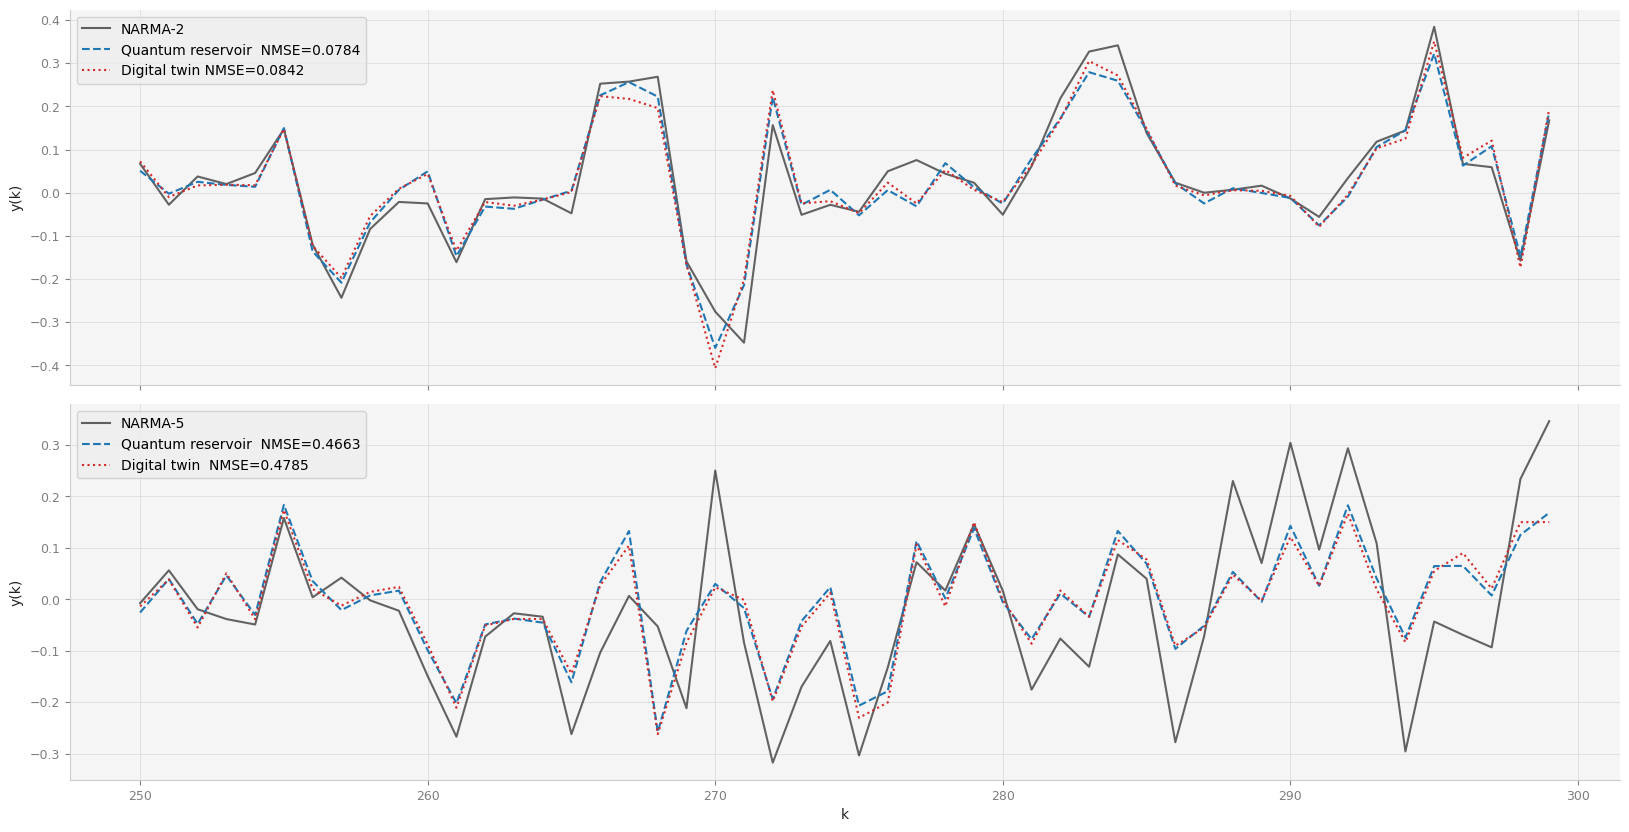

In [12]:
######################################
# The narma tasks
######################################

# The configs are for NARMA-5, they work as the default ones. Selected to avoid divergence
Narma_max_tau = 5
Narma_a= 0.3 #alpha
Narma_b= 0.05 # beta
Narma_g= 0.375 # gamma_N 
Narma_d= 0.0 # delta_N = 0 (no bias)
# Train and test sequence timesteps
Train_Narma= 100000  
Test_Narma = 2000
Narma_seed = 5555   # separate seed than for the one used in IPC 


# With this, different NARMA-tasks are easy to make
def narma_task(u, order=Narma_max_tau, a=Narma_a, b=Narma_b,
               c=Narma_g, d=Narma_d):
    """
    The NARMA equation itself
      y_{k+1} = a*y_k + b*y_k * sum(y_{k-tau}, tau=0..n-1) + c*s_{k-n+1}*s_k + d

    Changes to the standard NARMA :
      -> Missing y_k values initialized to 0
      -> s_{k} for k<0 uses wrap-around: s_{-1} = u[-1] 
    """
    T= len(u)
    y=np.zeros(T + 1)   
    u_ext = np.concatenate([u[-order+1:], u])  # prepend last (order-1) elements
    for k in range(T):
        y_sum=np.sum(y[max(0, k-order+1):k+1])
        s_past= u_ext[k]           
        s_curr= u[k]
        y[k+1]=a*y[k]+ b *y[k] * y_sum + c*s_past*s_curr + d

    return y[1:]   #return the sequence, same length as u

# Function for the NMSE, this uses the so called "similarity" in signal processing. Variance is replaced with the mean square value
# As the values in the sequence are small, it does not really matter if we use the mean square value or variance. 
def task_nmse(y_pred, y_true):
    squar_mean=np.mean(y_true**2)
    if squar_mean< 1e-12: 
        return 1.0
    return float(np.mean((y_true - y_pred)**2)/squar_mean)

# Function to train the readout. Ridge regression is used for this. The regularization uses alpha=lambda*N
def train_readout(X, y, Lambda=1e-4):
    X= np.nan_to_num(X,nan=0.0, posinf=0.0, neginf=0.0) # These checks for bad values
    y= np.nan_to_num(y,nan=0.0, posinf=0.0, neginf=0.0)
    #Standardization
    mean_x=X.mean(0, keepdims=True)
    standard_dev_x= X.std(0, keepdims=True) + 1e-12
    X_standardized= (X-mean_x)/standard_dev_x
  
    X_b= np.hstack([X_standardized, np.ones((len(X_standardized), 1))]) # The bias term
    A= X_b.T@X_b+Lambda * len(y)* np.eye(X_b.shape[1]) # The ridge matrix
    W= np.linalg.solve(A, X_b.T @ y) #The solution for the ridge matrix, similar to Moore-Penrose
    return W, mean_x, standard_dev_x   # return standardization stats too

#Function that applies the above readout, so uses the trained weights
def apply_readout(X, W, mean_x, standard_dev_x):
    X= np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0) # Clean the data again
    X_s=(X-mean_x) / (standard_dev_x + 1e-12)
    X_b=np.hstack([X_s, np.ones((len(X_s), 1))])
    return X_b @ W

    
######################################
# The digital twin, only gets the sequence and washout as parameters
######################################
def twin_reservoir(u_seq, washout=washout):
    """
    Uses the Legendre basis for the dynamics
    The polynomials are calculated again with the new input but the coefficients are from the IPC calculations above.
    """
    u= u_seq[washout:]  # To align with the reservoir 
    N= len(u)
    L= N-tau_max
    B= np.zeros((L, N_terms))  # The basis matrix again initialized
    for j, f in enumerate(terms): # These are all the paramaters for the terms
        tau_j= f["tau_max"]
        taus= f["taus"]
        ds= f["ds"]
        order=f["order"]
        offset=tau_max- tau_j
        Lj= N -tau_j
        if order==1:   # Go thorough the polynomials, single and cross-terms, The zero mean is not really necessary as the polynomials are normalized and have zero mean in -1 and 1. Does not really affect the result
            p=legendre_poly(u[:Lj], ds[0])
            
        elif order==2:
            o2= taus[0]-taus[1]
            p=(legendre_poly(u[:Lj], ds[0]) *
                  legendre_poly(u[o2:o2+Lj], ds[1]))
            
        else:
            o2=taus[0]-taus[1]
            o3=taus[0] - taus[2]
            p=(legendre_poly(u[:Lj], ds[0])*
                  legendre_poly(u[o2:o2+Lj], ds[1])*
                  legendre_poly(u[o3:o3+Lj], ds[2]))
            #p  = p - p.mean()
        B[:, j]=p[offset: offset + L]  
    return B@C_coeff @ W_inv + feature_mean # We inverse the operation to move back to original observable space





# Construct the NARMA-5 
Narma_N=washout + Train_Narma + Test_Narma
rng_narma=np.random.default_rng(Narma_seed)
u_narma=rng_narma.uniform(-1, 1, Narma_N)
y_narma=narma_task(u_narma)   

# Training target and testing split
y_tr_narma= y_narma[washout+tau_max : washout + Train_Narma]
y_te_narma= y_narma[washout + Train_Narma + tau_max :]




# First, the NARMA on the digital twin

# All these time counters are for runtime check
t0_tw = time.perf_counter()


#The twin features
X_twin = twin_reservoir(u_narma)

t1_tw=time.perf_counter()
twin_runtime = t1_tw - t0_tw  

# These are the twins target training and testing split. Also the features for the splits
y_tr_twin= y_narma[washout + tau_max : washout + Train_Narma]
y_te_twin= y_narma[washout + Train_Narma + tau_max :]
X_tr_twin= X_twin[:len(y_tr_twin)]
X_te_twin= X_twin[len(y_tr_twin) + tau_max :][:len(y_te_twin)]

X_twin_pauli_tr = X_tr_twin  
X_twin_pauli_te = X_te_twin   

# We use reconstructed Pauli observables directly
X_tw_tr_w = X_twin_pauli_tr
X_tw_te_w = X_twin_pauli_te


# Train and apply the readout. Calculate NMSE
W_twin, mean_twin, standard_dev_twin=train_readout(X_tw_tr_w, y_tr_twin)
y_pred_tr_twin=apply_readout(X_tw_tr_w, W_twin, mean_twin, standard_dev_twin)
y_pred_te_twin= apply_readout(X_tw_te_w, W_twin, mean_twin, standard_dev_twin)
nmse_tr_twin= task_nmse(y_pred_tr_twin, y_tr_twin)
nmse_te_twin= task_nmse(y_pred_te_twin, y_te_twin)


# The NARMA on the real reserovir, same procedure as above

t0_re = time.perf_counter()

# The features from NARMA
X_narma_full = run_reservoir(u_narma)

t1_re = time.perf_counter()
real_runtime = t1_re - t0_re
# Real reservoir 
X_tr_reser_stra= X_narma_full[washout : washout + Train_Narma]
X_tr_reser= X_tr_reser_stra[tau_max:] # align with twin
X_te_reser_stra =X_narma_full[washout + Train_Narma:]
X_te_reser= X_te_reser_stra[tau_max:][:len(y_te_narma)]  # align with twin




# Train and apply the readout. Calculate NMSE
W_reservoir, mean_reser, standard_dev_reser = train_readout(X_tr_reser, y_tr_narma)
y_pred_tr_reser= apply_readout(X_tr_reser, W_reservoir, mean_reser, standard_dev_reser)
y_pred_te_reser=apply_readout(X_te_reser, W_reservoir, mean_reser, standard_dev_reser)
nmse_tr_reser=task_nmse(y_pred_tr_reser, y_tr_narma)
nmse_te_reser=task_nmse(y_pred_te_reser, y_te_narma)

print(f"\n{"="*3}")
print(f"  NARMA-5 ")
print(f"{"="*3}")

print(f"  Real reservoir: {nmse_tr_reser:.4f} {nmse_te_reser:.4f}  runtime: {real_runtime:.4f} seconds")
print(f"  Digital twin: {nmse_tr_twin:.4f} {nmse_te_twin:.4f}  runtime: {twin_runtime:.4f} seconds")

print("  " + "-" * 52)
# NARMA-2 task
print(f"\n{"="*3}")
print(f"  NARMA-2  (Used the same observables from earlier run)")
print(f"{"="*3}")

y_narma2=narma_task(u_narma, order=2, a=Narma_a, b=Narma_b, c=Narma_g, d=Narma_d)
y_tr_narma2=y_narma2[washout + tau_max : washout + Train_Narma]
y_te_narma2= y_narma2[washout + Train_Narma + tau_max :]
y_tr_twin2= y_tr_narma2.copy()
y_te_twin2= y_te_narma2.copy()

W_reservoir_2, mean_reservoir2, standard_dev_reser2=train_readout(X_tr_reser, y_tr_narma2)
y_pred_tr_reser2= apply_readout(X_tr_reser, W_reservoir_2, mean_reservoir2, standard_dev_reser2)
y_pred_te_reser2= apply_readout(X_te_reser, W_reservoir_2, mean_reservoir2, standard_dev_reser2)
nmse_tr_reser2=task_nmse(y_pred_tr_reser2, y_tr_narma2)
nmse_te_reser2=task_nmse(y_pred_te_reser2, y_te_narma2)

W_twin2, mean_twin2, standard_dev_twin2 = train_readout(X_tw_tr_w, y_tr_twin2)
y_pred_tr_twin2= apply_readout(X_tw_tr_w, W_twin2, mean_twin2, standard_dev_twin2)
y_pred_te_twin2=apply_readout(X_tw_te_w, W_twin2, mean_twin2, standard_dev_twin2)
nmse_tr_twin2=task_nmse(y_pred_tr_twin2, y_tr_twin2)
nmse_te_twin2=task_nmse(y_pred_te_twin2, y_te_twin2)

print(f"  Real reservoir: Train={nmse_tr_reser2:.4f}  Test={nmse_te_reser2:.4f}")
print(f"  Digital twin:   Train={nmse_tr_twin2:.4f}  Test={nmse_te_twin2:.4f}")

# The plot
start=250
end= 300
n_plot= min(end, len(y_te_narma))
n_p2= min(end, len(y_te_narma2))
t_plot=np.arange(start, end)

fig_narma, (ax_n2_ts, ax_n5_ts)=plt.subplots(
    2, 1, figsize=(20, 10),
    gridspec_kw={"hspace": 0.05})
fig_narma.patch.set_facecolor(BG)

# NARMA-2
ax_n2_ts.plot(t_plot, y_te_narma2[start:n_p2],color="black", lw=1.5, alpha=0.6, label="NARMA-2")
ax_n2_ts.plot(t_plot, y_pred_te_reser2[start:n_p2], color=BLUE,   lw=1.5, ls="--",
              label=f"Quantum reservoir  NMSE={nmse_te_reser2:.4f}")
ax_n2_ts.plot(t_plot, y_pred_te_twin2[start:n_p2], color=ORANGE, lw=1.5, ls=":",
              label=f"Digital twin NMSE={nmse_te_twin2:.4f}")
ax_n2_ts.set_ylabel("y(k)", color=TEXT)
ax_n2_ts.legend(fontsize=10, facecolor="#eeeeee", edgecolor=BORDER, loc="upper left")
ax_n2_ts.tick_params(labelbottom=False) 
style_ax(ax_n2_ts, "")

# NARMA-5
ax_n5_ts.plot(t_plot, y_te_narma[start:n_plot],       color="black", lw=1.5, alpha=0.6, label="NARMA-5")
ax_n5_ts.plot(t_plot, y_pred_te_reser[start:n_plot], color=BLUE,   lw=1.5, ls="--",
              label=f"Quantum reservoir  NMSE={nmse_te_reser:.4f}")
ax_n5_ts.plot(t_plot, y_pred_te_twin[start:n_plot], color=ORANGE, lw=1.5, ls=":",
              label=f"Digital twin  NMSE={nmse_te_twin:.4f}")
ax_n5_ts.set_ylabel("y(k)", color=TEXT)
ax_n5_ts.set_xlabel("k", color=TEXT)
ax_n5_ts.legend(fontsize=10, facecolor="#eeeeee", edgecolor=BORDER, loc="upper left")
style_ax(ax_n5_ts, "")

plt.show()



Running input
4000/5000


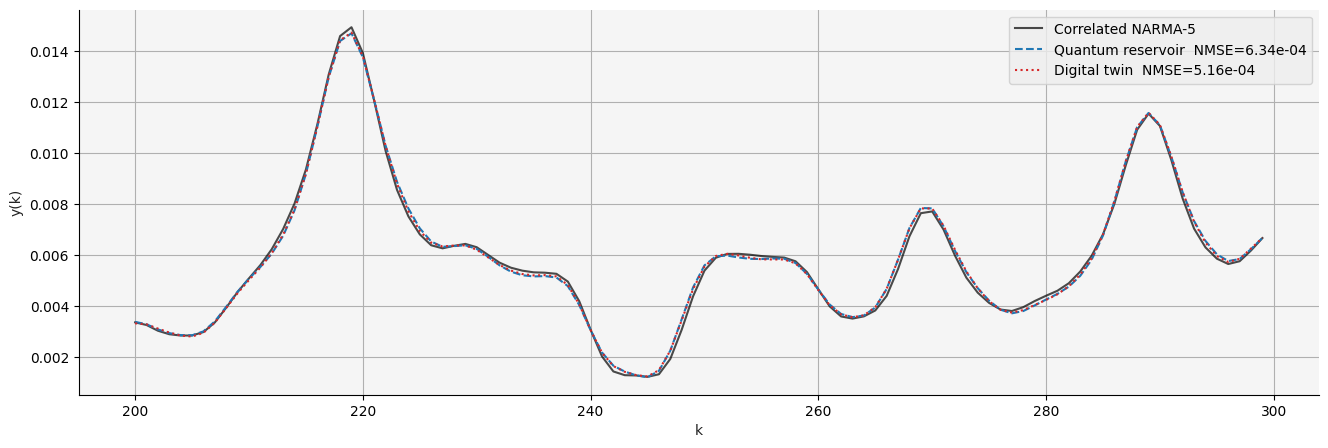

In [14]:
############################################
# Narma-5 on correlated input
############################################

# s_k=0.1*(sin(2π·2.11k/T)*sin(2π·3.73k/T)*sin(2π·4.11k/T) + 1)
# s_k ∈ [0, 0.2]

Sin_a= 2.11
Sin_b=3.73 
Sin_g= 4.11
Sin_T= 100
Sin_wash=1000
Sin_train= 3000
Sin_test= 1000
Sin_Narma= Sin_wash+ Sin_train+ Sin_test  

k_si = np.arange(Sin_Narma)
s_ori = 0.1 * (np.sin(2*np.pi*Sin_a*k_si/Sin_T)
             * np.sin(2*np.pi*Sin_b*k_si/Sin_T)
             * np.sin(2*np.pi*Sin_g*k_si/Sin_T) + 1.0)  


y_sine = narma_task(s_ori)

# Real reservoir
X_sin_full =run_reservoir(s_ori)
X_sin_tr=X_sin_full[Sin_wash : Sin_wash + Sin_train][tau_max:]
X_sin_te=X_sin_full[Sin_wash + Sin_train:][tau_max:]
y_sin_tr=y_sine[Sin_wash + tau_max : Sin_wash + Sin_train]
y_sin_te= y_sine[Sin_wash + Sin_train + tau_max:]

assert len(X_sin_tr)==len(y_sin_tr), f"Real alignment: {len(X_sin_tr)} vs {len(y_sin_tr)}"
assert len(X_sin_te)==len(y_sin_te), f"Real alignment: {len(X_sin_te)} vs {len(y_sin_te)}"

W_sin, mean_sin, standard_dev_sin= train_readout(X_sin_tr, y_sin_tr)
y_pred_si_te= apply_readout(X_sin_te, W_sin, mean_sin, standard_dev_sin)
nmse_si_re_te=task_nmse(y_pred_si_te, y_sin_te)


# The twin
X_sin_twin= twin_reservoir(s_ori, Sin_wash)
N_sin_tr= Sin_train - tau_max
X_sin_tr_twin=X_sin_twin[:N_sin_tr]
X_sin_te_twin=X_sin_twin[N_sin_tr + tau_max:][:len(y_sin_te)]


W_sin_twin, mean_sin_twin, standard_dev_sin_twin=train_readout(X_sin_tr_twin, y_sin_tr)
y_pred_si_tw_te=apply_readout(X_sin_te_twin, W_sin_twin, mean_sin_twin, standard_dev_sin_twin)
nmse_si_tw_te= task_nmse(y_pred_si_tw_te, y_sin_te)

#Plot
plot_s_si= 200
plot_e_si= min(300, len(y_sin_te))
t_si= np.arange(plot_s_si, plot_e_si)
fig_sine, ax_si = plt.subplots(figsize=(16, 5))
fig_sine.patch.set_facecolor(BG)
ax_si.set_facecolor(PANEL)
ax_si.grid(True)
ax_si.plot(t_si, y_sin_te[plot_s_si:plot_e_si],
           color="black", lw=1.5, alpha=0.7, label="Correlated NARMA-5 ")
ax_si.plot(t_si, y_pred_si_te[plot_s_si:plot_e_si],
           color=BLUE, lw=1.5, ls="--",
           label=f"Quantum reservoir  NMSE={nmse_si_re_te:.2e}")
ax_si.plot(t_si, y_pred_si_tw_te[plot_s_si:plot_e_si],
           color=ORANGE, lw=1.5, ls=":",
           label=f"Digital twin  NMSE={nmse_si_tw_te:.2e}")
ax_si.set_xlabel("k", color=TEXT)
ax_si.set_ylabel("y(k)", color=TEXT)
ax_si.legend(fontsize=10, facecolor="#eeeeee", edgecolor=BORDER)
style_ax(ax_n5_ts, "")

plt.show()


  σ=0.10
Running input
4000/102100
8000/102100
12000/102100
16000/102100
20000/102100
24000/102100
28000/102100
32000/102100
36000/102100
40000/102100
44000/102100
48000/102100
52000/102100
56000/102100
60000/102100
64000/102100
68000/102100
72000/102100
76000/102100
80000/102100
84000/102100
88000/102100
92000/102100
96000/102100
100000/102100
    seed=20: Real=0.00000  Twin=0.00000
  σ=0.20
Running input
4000/102100
8000/102100
12000/102100
16000/102100
20000/102100
24000/102100
28000/102100
32000/102100
36000/102100
40000/102100
44000/102100
48000/102100
52000/102100
56000/102100
60000/102100
64000/102100
68000/102100
72000/102100
76000/102100
80000/102100
84000/102100
88000/102100
92000/102100
96000/102100
100000/102100
    seed=20: Real=0.00003  Twin=0.00002
  σ=0.33
Running input
4000/102100
8000/102100
12000/102100
16000/102100
20000/102100
24000/102100
28000/102100
32000/102100
36000/102100
40000/102100
44000/102100
48000/102100
52000/102100
56000/102100
60000/102100
64000/1021

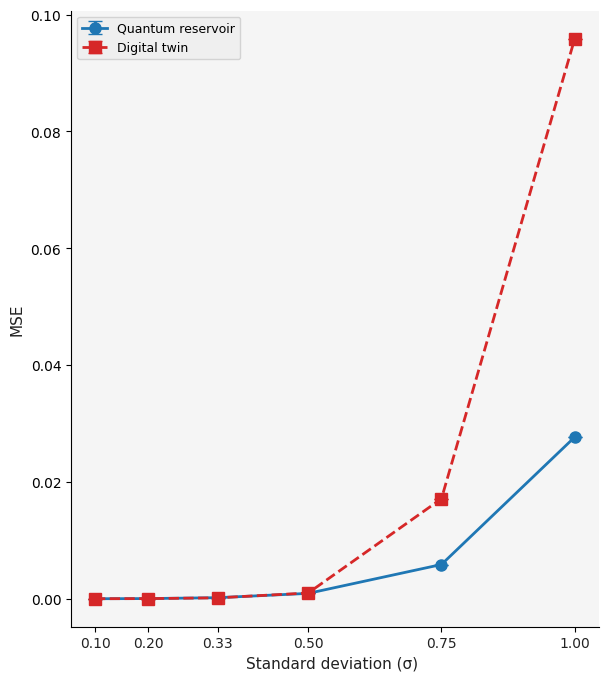

In [ ]:


######################################
# The input distribution sweep using input that is normally distributed
# The standard deviation is also changed to study how the reservoir handles larger distribution
# The narma task itself starts to diverge when the distribution is large -> performance suffers in a way that is not related to the twin and the reservoir
# For reduced runtime, in the commited code, only one seed is used
######################################




input_standard_deviations = [0.1, 0.2, 0.33, 0.5, 0.75, 1.0]

Sweep_seeds= [20,] #For reduced running time only one seed
sweep_results= []
for sigma in input_standard_deviations:
    print(f"  σ={sigma:.2f}", flush=True)
    re_list= []
    tw_list= []

    # Go through the seeds and generate an input    
    for seed in Sweep_seeds:
        rng_sw = np.random.default_rng(seed)
        s_normal= rng_sw.normal(0, sigma, Narma_N)
        y_s= narma_task(s_normal, order=2)

        # Real reservoir
        X_s_full=run_reservoir(s_normal)
        X_s_tr=X_s_full[washout:washout+ Train_Narma][tau_max:]
        X_s_te=X_s_full[washout+Train_Narma:][tau_max:]
        y_s_tr=y_s[washout + tau_max : washout + Train_Narma]
        y_s_te=y_s[washout + Train_Narma + tau_max:]

        W_sweep_real, mean_sweep_real, standard_dev_sweep_real = train_readout(X_s_tr, y_s_tr)
        mse_sweep_real= float(np.mean((apply_readout(X_s_te, W_sweep_real, mean_sweep_real, standard_dev_sweep_real) - y_s_te)**2))
        re_list.append(mse_sweep_real)

        # Twin
        twin_reservoir(s_normal, washout)
        X_tw=np.clip(twin_reservoir(s_normal, washout),-1e6,1e6)
        N_tr_tw=Train_Narma-tau_max
        X_tw_tr_s=X_tw[:N_tr_tw]
        X_tw_te_s=X_tw[N_tr_tw+tau_max:][:len(y_s_te)]

        W_sweep_twin,mean_sweep_twin,standard_dev_sweep_twin=train_readout(X_tw_tr_s,y_s_tr)
        mse_sweep_twin=float(np.mean((apply_readout(X_tw_te_s,W_sweep_twin,mean_sweep_twin,standard_dev_sweep_twin)-y_s_te)**2))
        tw_list.append(mse_sweep_twin)
        print(f"    seed={seed}: Real={mse_sweep_real:.5f}  Twin={mse_sweep_twin:.5f}")

    sweep_results.append((sigma,
                          np.mean(re_list), np.std(re_list),
                          np.mean(tw_list), np.std(tw_list)))
    

# Plot
sigmas= [r[0] for r in sweep_results]
mean_real= np.array([r[1] for r in sweep_results])
standrad_real=np.array([r[2] for r in sweep_results])
mean_twin=np.array([r[3] for r in sweep_results])
standard_twin=np.array([r[4] for r in sweep_results])
mse_difference=np.abs(mean_twin - mean_real)
standard_difference =np.sqrt(standrad_real**2 + standard_twin**2)


fig_sweep=plt.figure(figsize=(16, 8))
fig_sweep.patch.set_facecolor(BG)
gs_sw= gridspec.GridSpec(1, 2, figure=fig_sweep, wspace=0.35)

ax_sw1= fig_sweep.add_subplot(gs_sw[0, 0])
ax_sw1.set_facecolor(PANEL)
ax_sw1.errorbar(sigmas, mean_real, yerr=standrad_real, fmt="o-", color=BLUE,
                lw=2, markersize=8, capsize=5, label="Quantum reservoir")
ax_sw1.errorbar(sigmas, mean_twin, yerr=standard_twin, fmt="s--", color=ORANGE,
                lw=2, markersize=8, capsize=5, label="Digital twin")
ax_sw1.set_xlabel("Standard deviation (σ) ", color=TEXT, fontsize=11)
ax_sw1.set_ylabel("MSE", color=TEXT, fontsize=11)
ax_sw1.set_xticks(sigmas)
ax_sw1.set_xticklabels([f"{s:.2f}" for s in sigmas], color=TEXT)
ax_sw1.legend(fontsize=9, facecolor="#eeeeee", edgecolor=BORDER, loc="upper left")
plt.show()
